# 06 — Parse fixed-format text

**Access pattern: a gzipped, column-oriented text file with a two-line header.** No
API, no structure, no self-description. This is the oldest pattern here and still the
one that quietly corrupts your analysis, because nothing in it raises an error.

Deliberately the shortest notebook. It is the least abstract pattern, and it lands well
after the harder ones.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

offline mode: serving prefetched responses


## 1. What it looks like

NDBC moored meteorological data, one file per station-year, gzipped:

```
https://www.ndbc.noaa.gov/data/historical/stdmet/46092h2019.txt.gz
```

In [2]:
import gzip

res = _fetch.get(S.ndbc_url(), quiet=True)
text = gzip.decompress(res.content).decode()
lines = text.splitlines()

print(f"  {len(res.content):,} bytes gzipped -> {len(text):,} bytes, {len(lines):,} lines")
print()
for i in range(4):
    tag = "NAMES" if i == 0 else "UNITS" if i == 1 else "data"
    print(f"  [{tag}] {lines[i][:74]}")

  76,016 bytes gzipped -> 697,493 bytes, 7,837 lines

  [NAMES] #YY  MM DD hh mm WDIR WSPD GST  WVHT   DPD   APD MWD   PRES  ATMP  WTMP  D
  [UNITS] #yr  mo dy hr mn degT m/s  m/s     m   sec   sec degT   hPa  degC  degC  d
  [data] 2019 01 05 19 12 130 10.3 99.0 99.00 99.00 99.00 999 1005.7  13.9  13.1 99
  [data] 2019 01 05 20 12 160 11.8 99.0 99.00 99.00 99.00 999 1006.3  13.5  13.2 99


### ⚠️ Trap — line 0 is the names, line 1 is the units, data starts at line 2

Parse line 1 instead of line 0 and every column comes out named `#yr`, `mo`, `dy`, `hr`,
`mn` instead of `YY`, `MM`, `DD`, `hh`, `mm`. No error. The file parses perfectly. The
bug is that your code now refers to `frame["MM"]` and gets a `KeyError` an hour later,
far from the cause.

The giveaway is the `#` prefix in the units line — the file marks the units row as a
comment, which is why the names row also carries a `#`.

In [3]:
cols = [c.lstrip("#") for c in lines[0].split()]
print("  parsed from line 0 (correct):", cols[:8])
print("  parsed from line 1 (wrong)  :", [c.lstrip("#") for c in lines[1].split()][:8])
print()
print("  data rows:", len([l for l in lines[2:] if l.strip()]))
print()
print("  Note it is the NAMES line that is prefixed with '#', not the units line --")
print("  so 'strip the #' is not a reliable way to find the header either.")

  parsed from line 0 (correct): ['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR', 'WSPD', 'GST']
  parsed from line 1 (wrong)  : ['yr', 'mo', 'dy', 'hr', 'mn', 'degT', 'm/s', 'm/s']

  data rows: 7835

  Note it is the NAMES line that is prefixed with '#', not the units line --
  so 'strip the #' is not a reliable way to find the header either.


### ⚠️ Trap — the resolution is **not** uniform

A year of hourly data is 8,760 rows. This file has **7,835**. Timestamps are stamped
about 50 minutes past the hour, and UTC.

The span starts on 5 January, not 1 January — the first days are simply absent. So
"hourly" is a description of intent, not of the file. Never assume a cadence; always
check, and resample explicitly.

In [4]:
raw = pd.DataFrame([l.split() for l in lines[2:] if l.strip()], columns=cols)
stamps = pd.to_datetime(
    dict(year=pd.to_numeric(raw.YY), month=pd.to_numeric(raw.MM),
         day=pd.to_numeric(raw.DD), hour=pd.to_numeric(raw.hh),
         minute=pd.to_numeric(raw.mm)),
    utc=True,
).dt.tz_localize(None)

print(f"  rows            : {len(stamps):,}")
print(f"  span            : {stamps.min()}  ->  {stamps.max()}")
print(f"  a full year 2019 is 8,760 hours; this file has {len(stamps):,}")
print(f"  distinct hours  : {stamps.dt.floor('h').nunique():,}")
print(f"  missing minutes : {stamps.dt.minute.value_counts().head(3).to_dict()}")
print()
gap = pd.Series(stamps).diff().dt.total_seconds().div(3600)
print(f"  most common gap : {gap.value_counts().head(3).to_dict()} hours")
print("  -> resample explicitly before any arithmetic that assumes hourly.")

  rows            : 7,835
  span            : 2019-01-05 19:12:00  ->  2019-12-31 23:07:00
  a full year 2019 is 8,760 hours; this file has 7,835
  distinct hours  : 7,834
  missing minutes : {13: 2049, 14: 1592, 11: 1228}

  most common gap : {1.0: 7415, 1.1666666666666667: 145, 0.8333333333333334: 139} hours
  -> resample explicitly before any arithmetic that assumes hourly.


### ⚠️ Trap — missing-value sentinels differ per column, and 99 is a valid bearing

Most fields use `99.0` for missing. But `WDIR`, `MWD` and `PRES` use `999.0` /
`9999.0`. And a blanket `>= 99` filter on wind direction **deletes real easterly
winds** — 99° is a perfectly ordinary direction.

| column | sentinel |
|---|---|
| `WSPD`, `GST`, `WVHT`, `DPD`, `APD`, `ATMP`, `WTMP`, `DEWP`, `VIS`, `TIDE` | 99.0 |
| `WDIR`, `MWD` | 999.0 |
| `PRES` | 9999.0 |

Worth being precise about: **in this particular file, for 2019, neither 99 nor 999
appears in `WDIR` at all** (measured below). The bug is latent rather than observed
here — which is worse, because a missing-data handler that quietly deletes a degree of
wind direction will not announce itself until someone plots the compass rose.

In [5]:
wd = pd.to_numeric(raw.WDIR, errors="coerce")
print(f"  WDIR: {wd.min():.0f} - {wd.max():.0f} deg")
print(f"  values equal to 99  : {(wd == 99).sum()}")
print(f"  values equal to 999 : {(wd == 999).sum()}")
print()
print("  So for 2019 at this station the sentinel does not occur. The trap is still")
print("  real: a handler written as 'WDIR >= 99 is missing' removes valid bearings")
print("  whenever the sentinel is 999, and silently biases any direction rose.")
print()
# What a blanket filter would cost, in a year that does contain 99s.
n_would_drop = int((wd.between(99, 99)).sum())
print(f"  a blanket >= 99 filter would drop {n_would_drop} rows here, and would drop")
print("  real data in any file where 99 deg is reported.")

  WDIR: 0 - 360 deg
  values equal to 99  : 0
  values equal to 999 : 0

  So for 2019 at this station the sentinel does not occur. The trap is still
  real: a handler written as 'WDIR >= 99 is missing' removes valid bearings
  whenever the sentinel is 999, and silently biases any direction rose.

  a blanket >= 99 filter would drop 0 rows here, and would drop
  real data in any file where 99 deg is reported.


## 2. Wind is a vector, and direction is *from*

Two conventions that are easy to get backwards:

1. `WDIR` is the direction the wind comes **from**, in degrees true. 350° is wind from
   the north, blowing south.
2. The components below point where the air is **going**, so they carry a sign flip.

In [6]:
wspd = pd.to_numeric(raw.WSPD, errors="coerce").replace(99.0, np.nan)
wdir = pd.to_numeric(raw.WDIR, errors="coerce").replace(999.0, np.nan)

rad = np.radians(wdir)
u = -wspd * np.sin(rad)      # eastward component
v = -wspd * np.cos(rad)      # northward component
# The northerly component: POSITIVE when wind blows FROM the north. This is the one
# that drives upwelling on the California coast, so sign convention matters a lot.
northerly = wspd * np.cos(rad)

# ⚠️ `.to_numpy()` on every one of these, and that is not stylistic.
# Passing a Series into DataFrame(..., index=<DatetimeIndex>) makes pandas ALIGN ON
# INDEX. These Series carry a RangeIndex 0..7834, the frame carries timestamps, no
# labels match, and every column comes out NaN. No error, no warning -- just a
# column of missing data that looks exactly like a column of missing data.
frame = pd.DataFrame({"wspd": wspd.to_numpy(), "wdir": wdir.to_numpy(),
                      "u": u.to_numpy(), "v": v.to_numpy(),
                      "northerly": northerly.to_numpy()}, index=stamps)

# Show the failure, so it is recognisable next time.
wrong = pd.DataFrame({"wspd": wspd}, index=stamps)   # the bug
print("  with .to_numpy()   -> mean wind speed", f"{frame.wspd.mean():.2f} m/s")
print("  without it (the bug)-> mean wind speed", f"{wrong.wspd.mean():.2f} m/s")
print()
print(f"  mean northerly component: {frame.northerly.mean():+.2f} m/s")
print()
print("  A negative mean northerly component means the wind predominantly blows")
print("  FROM the south -- downwelling-favourable on this coast. A positive value is")
print("  upwelling-favourable.")

  with .to_numpy()   -> mean wind speed 4.91 m/s
  without it (the bug)-> mean wind speed nan m/s

  mean northerly component: +0.57 m/s

  A negative mean northerly component means the wind predominantly blows
  FROM the south -- downwelling-favourable on this coast. A positive value is
  upwelling-favourable.


### ⚠️ Trap — you cannot average a compass bearing

Bearings wrap. The naive mean of 350° and 10° is **180°** — the exact opposite of 0°.
For any month with wind from both sides of north, a plain `.mean()` gives you a
direction nobody experienced.

The fix is to average the unit vectors instead, which is exactly what `u` and `v` above
already are:

```
mean direction = atan2(mean(u), mean(v))
```

In [7]:
def circular_mean_deg(degrees):
    """Mean of bearings. Bearings wrap, so average the vectors, not the degrees."""
    r = np.radians(pd.Series(degrees).dropna())
    if r.empty:
        return float("nan")
    return float((np.degrees(np.arctan2(np.sin(r).mean(), np.cos(r).mean())) + 360) % 360)

naive = frame.wdir.mean()
correct = circular_mean_deg(frame.wdir)
print(f"  naive  .mean()   : {naive:6.1f} deg")
print(f"  circular mean    : {correct:6.1f} deg")
print(f"  difference       : {abs(naive - correct):6.1f} deg")
print()
print("  Demonstration of why: bearings either side of north.")
demo = [350, 10]
print(f"    {demo}  naive mean = {np.mean(demo):.1f} deg, circular = {circular_mean_deg(demo):.1f} deg")
print("    The naive answer is due south. The wind was from the north.")

  naive  .mean()   :  217.3 deg
  circular mean    :  296.9 deg
  difference       :   79.6 deg

  Demonstration of why: bearings either side of north.
    [350, 10]  naive mean = 180.0 deg, circular = 0.0 deg
    The naive answer is due south. The wind was from the north.


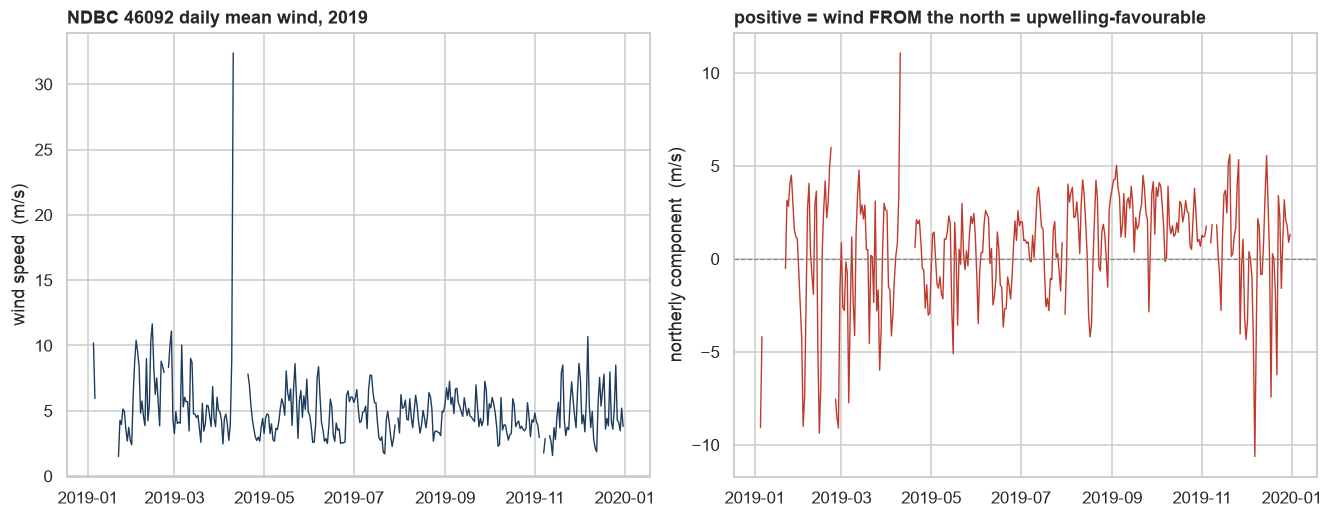

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

daily = frame.resample("1D").agg(
    wind_speed=("wspd", "mean"),
    northerly=("northerly", "mean"),
    u=("u", "mean"), v=("v", "mean"),
)
daily["dir"] = [circular_mean_deg(g.wdir) for _, g in frame.resample("1D")]
axes[0].plot(daily.index, daily.wind_speed, color="#1b3a5c", lw=0.9)
axes[0].set_ylabel("wind speed  (m/s)")
axes[0].set_title(f"NDBC {S.WIND_STATION} daily mean wind, 2019", loc="left", fontweight="bold")

axes[1].plot(daily.index, daily.northerly, color="#c0392b", lw=0.9)
axes[1].axhline(0, color="#888", lw=0.8, ls="--")
axes[1].set_ylabel("northerly component  (m/s)")
axes[1].set_title("positive = wind FROM the north = upwelling-favourable",
                  loc="left", fontweight="bold")

plt.show()

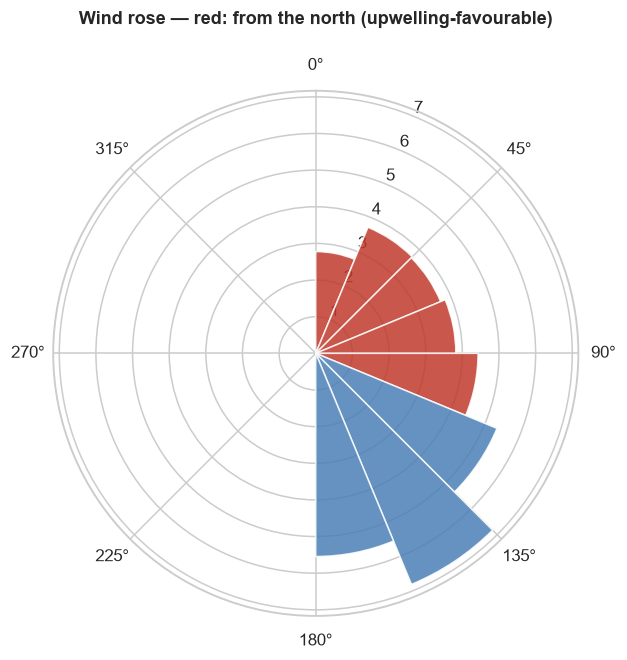

  16 sectors, 7,835 observations
  fastest sector mean: 6.83 m/s


In [9]:
# Wind rose, done correctly: bin the vectors, not the bearings.
n = len(frame)
bins = 16
theta = np.radians(frame.wdir)
edges = np.linspace(-np.pi, np.pi, bins + 1)
idx = np.digitize(theta, edges) - 1
speeds = frame.wspd.to_numpy()

fig = plt.figure(figsize=(7, 6.2))
ax = fig.add_subplot(111, polar=True)
radii, colours = [], []
for b in range(bins):
    m = (idx == b) & ~np.isnan(speeds)
    radii.append(float(speeds[m].mean()) if m.any() else 0.0)
    colours.append("#c0392b" if np.cos(edges[b]) > 0 else "#4a7fb5")
ax.bar(edges[:-1] + np.pi / bins, radii, width=2 * np.pi / bins, color=colours, alpha=0.85)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Wind rose — red: from the north (upwelling-favourable)",
             pad=22, fontweight="bold")
plt.show()

print(f"  {bins} sectors, {n:,} observations")
print(f"  fastest sector mean: {max(radii):.2f} m/s")

In [10]:
_fetch.expect("data rows", len(stamps), 7835)
_fetch.expect("columns", cols[:6], ["YY", "MM", "DD", "hh", "mm", "WDIR"])
_fetch.expect_range("mean wind speed", float(frame.wspd.mean()), 3.0, 12.0)
_fetch.expect_range("mean northerly", float(frame.northerly.mean()), -8.0, 8.0)
_fetch.expect("naive != circular", abs(naive - correct) > 0.01, True)
print()
print("  The last assertion is the one that matters. If a naive bearing mean and a")
print("  circular mean agree, either the wind did not cross north, or your circular")
print("  mean is not doing anything. They should differ.")

  ok  data rows: got 7835, expected 7835
  ok  columns: got ['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR'], expected ['YY', 'MM', 'DD', 'hh', 'mm', 'WDIR']
  ok  mean wind speed: 4.912895987328406 in [3.0, 12.0]
  ok  mean northerly: 0.5702219402345069 in [-8.0, 8.0]
  ok  naive != circular: got np.True_, expected True

  The last assertion is the one that matters. If a naive bearing mean and a
  circular mean agree, either the wind did not cross north, or your circular
  mean is not doing anything. They should differ.
